<a href="https://colab.research.google.com/github/krushna1133/NNDL-Practical/blob/main/NNDL_Practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 784)
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0666 - val_loss: 0.0584
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0509 - val_loss: 0.0438
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0412 - val_loss: 0.0379
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0358 - val_loss: 0.0333
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0320 - val_loss: 0.0302
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0294 - val_loss: 0.0279
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0274 - val_loss: 0.0263
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0259 - val_loss: 0.0247
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0244 - val_loss: 0.0235
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0232 - val_loss: 0.0223
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

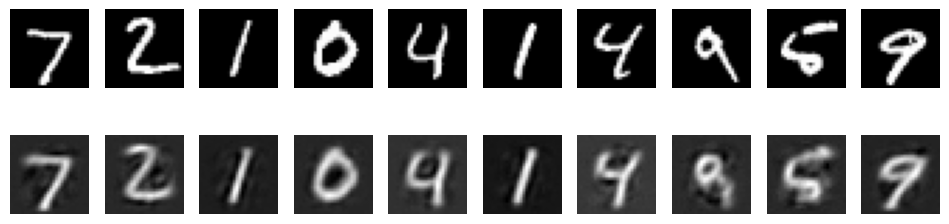

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images: 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)


# Autoencoder
class AutoEncoder(tf.keras.Model):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder1 = tf.keras.layers.Dense(256, activation="sigmoid")
        self.encoder2 = tf.keras.layers.Dense(128, activation="sigmoid")
        self.encoder_final = tf.keras.layers.Dense(32, activation="relu")

        # Decoder
        self.decoder1 = tf.keras.layers.Dense(128, activation="sigmoid")
        self.decoder2 = tf.keras.layers.Dense(256, activation="sigmoid")
        self.decoder_final = tf.keras.layers.Dense(784)

    def call(self, x):

        # Encoding
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.encoder_final(x)

        # Decoding
        x = self.decoder1(x)
        x = self.decoder2(x)
        x = self.decoder_final(x)

        return x


# Create model
model = AutoEncoder()

# Compile model
model.compile(
    optimizer="adam",
    loss="mse"
)

# Train model
model.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

print("Training completed!")


# Test images
test_images = x_test[:10]

# Reconstruct images
reconstructed = model(test_images)


# Display original and reconstructed images
plt.figure(figsize=(12, 3))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].numpy().reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()
